CLASSIC ML

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import (ExtraTreesRegressor, BaggingRegressor, RandomForestRegressor,
                              GradientBoostingRegressor, HistGradientBoostingRegressor)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from scipy.ndimage import gaussian_filter1d

In [ ]:
# Load data
df = pd.read_csv('data/final_data_exchange_bias.csv')
core, shell, formula = df['core'], df['shell'], df['formula']
df = df.drop(columns=['core', 'shell', 'formula'])


# Preprocessing
y = df['exc_bias_oe']
y = y[y > 0]  # Filter only positive values

# Apply smoothing to the target variable
y_smooth = gaussian_filter1d(y, sigma=2)
# Logarithmic transformation of the smoothed target variable
y_log = np.log10(y_smooth)

# Feature generation
X = df[df['exc_bias_oe'] > 0].drop(columns=['exc_bias_oe'])

# Apply KNN Imputer to fill missing values
knn_imputer = KNNImputer(n_neighbors=5)
X_imputed = knn_imputer.fit_transform(X)


# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_log, test_size=0.2, random_state=1984)

# Further split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.0639, random_state=1984)

# Scaling the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [5]:
models = models = {
    'Bagging': BaggingRegressor(n_estimators=300, max_samples=0.9776911085655549,
                                   max_features=0.31309603223233823, bootstrap=False, random_state=1984),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=348, max_depth=76, min_samples_split=2,
                                         min_samples_leaf=2, bootstrap=False, max_features=None, ccp_alpha=0, random_state=1984),
    'RandomForest': RandomForestRegressor(n_estimators=384, max_depth=65, min_samples_split=3,
                                             min_samples_leaf=2, bootstrap=False, max_features='log2', random_state=1984),
    'XGB': XGBRegressor(n_estimators=424, max_depth=22, learning_rate=0.029775486467142665,
                           subsample=0.7358573421632647, colsample_bytree=0.5128835927539236, gamma=0.001178216687382395,
                           reg_alpha=0.3688362981967942, reg_lambda=0.9581849266893232, min_child_weight=4,
                           scale_pos_weight=9.787498596663324, random_state=1984),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=450, max_depth=39, learning_rate=0.03325774896721734,
                                                  subsample=0.5249255381726716, min_samples_split=18, min_samples_leaf=3, random_state=1984),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=466, max_depth=22, learning_rate=0.11068107159769078,
                                                            max_leaf_nodes=87, min_samples_leaf=35, random_state=1984),
    'LGBM': LGBMRegressor(n_estimators=410, max_depth=27, learning_rate=0.06189087491958441, num_leaves=60,
                            min_data_in_leaf=22, feature_fraction=0.5107580106941778, scale_pos_weight=19.965009642913554,
                            reg_alpha=0.061407641972931915, reg_lambda=0.5275644028683729, bagging_fraction=0.8938154558415361,
                            bagging_freq=4, random_state=1984, verbose=-1),
}

Training Bagging...
Bagging - RMSE (CV): 0.2462, Q² (CV): 0.7750, MAE (CV): 0.1789
Bagging - Validation RMSE: 0.2409, Validation R²: 0.7779, Validation MAE: 0.1749
Bagging - Test RMSE: 0.2389, Test R²: 0.7473, Test MAE: 0.1720
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 0.33983036542631223, 3.0099771957015946
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 0.9695405585167841, 2.9078020446595163
Min/Max y_test: 0.712456041114732, 2.9922494242869937
Min/Max y_test_pred: 0.9562953641529837, 3.0026825496154714


C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:106: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line + avg_rmse, 'b--', label=f'RMSE bound', linestyle=':')
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:107: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line - avg_rmse, 'b--', linestyle=':')


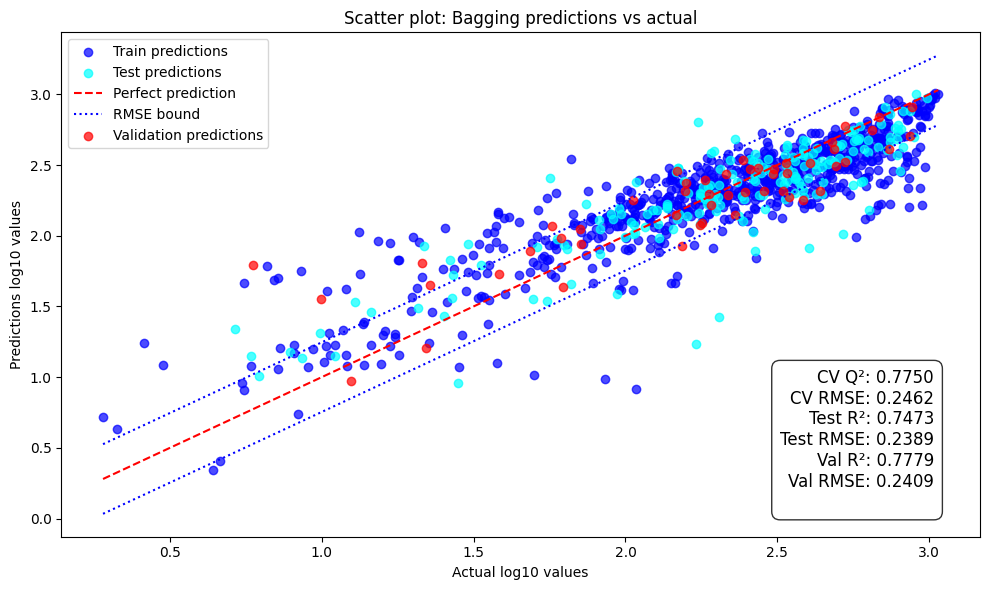

Training ExtraTrees...
ExtraTrees - RMSE (CV): 0.2661, Q² (CV): 0.7381, MAE (CV): 0.1897
ExtraTrees - Validation RMSE: 0.2712, Validation R²: 0.7187, Validation MAE: 0.1765
ExtraTrees - Test RMSE: 0.2381, Test R²: 0.7490, Test MAE: 0.1704
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 0.4385125041429034, 2.9794072917522687
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.0501154997693436, 2.930581187782834
Min/Max y_test: 0.712456041114732, 2.9922494242869937
Min/Max y_test_pred: 0.7996519102548383, 2.9977741973809864


C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:106: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line + avg_rmse, 'b--', label=f'RMSE bound', linestyle=':')
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:107: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line - avg_rmse, 'b--', linestyle=':')


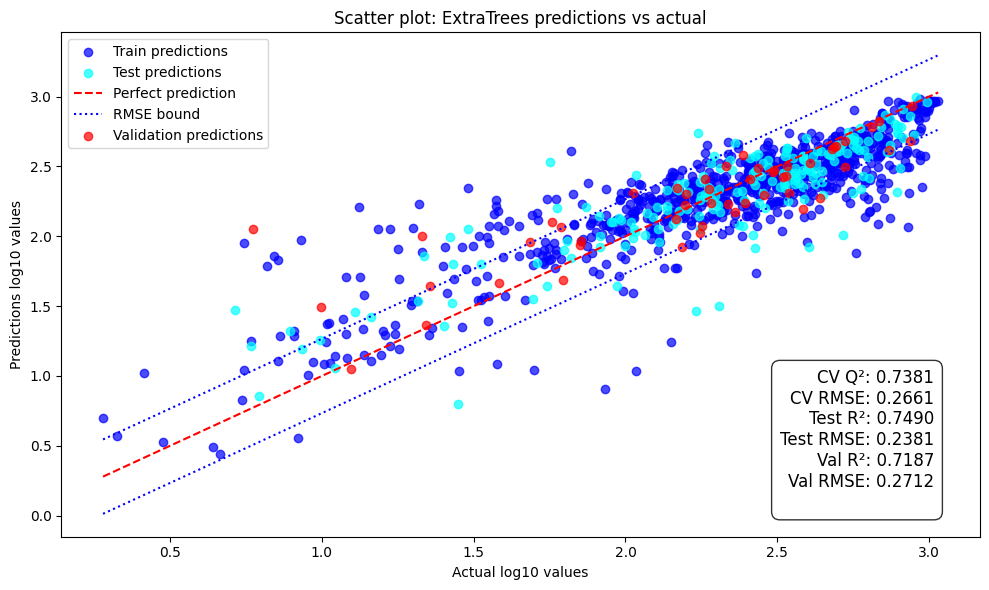

Training RandomForest...
RandomForest - RMSE (CV): 0.2569, Q² (CV): 0.7546, MAE (CV): 0.1856
RandomForest - Validation RMSE: 0.2543, Validation R²: 0.7525, Validation MAE: 0.1765
RandomForest - Test RMSE: 0.2453, Test R²: 0.7336, Test MAE: 0.1807
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 0.4645126204383805, 2.9753528282558825
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.0449510477109019, 2.9178030632961143
Min/Max y_test: 0.712456041114732, 2.9922494242869937
Min/Max y_test_pred: 0.885855188678551, 2.99557854369561


C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:106: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line + avg_rmse, 'b--', label=f'RMSE bound', linestyle=':')
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:107: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line - avg_rmse, 'b--', linestyle=':')


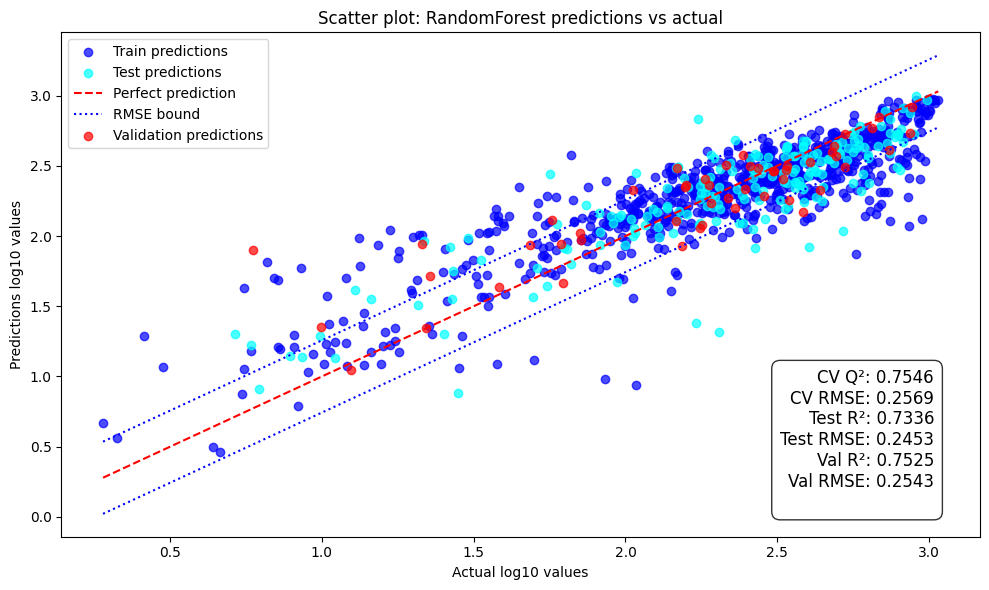

Training XGB...
XGB - RMSE (CV): 0.2595, Q² (CV): 0.7462, MAE (CV): 0.1851
XGB - Validation RMSE: 0.2447, Validation R²: 0.7709, Validation MAE: 0.1749
XGB - Test RMSE: 0.2484, Test R²: 0.7268, Test MAE: 0.1812
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 0.394018292427063, 2.9988105297088623
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.0188781023025513, 2.9056575298309326
Min/Max y_test: 0.712456041114732, 2.9922494242869937
Min/Max y_test_pred: 0.7750663757324219, 2.9894235134124756


C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:106: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line + avg_rmse, 'b--', label=f'RMSE bound', linestyle=':')
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:107: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line - avg_rmse, 'b--', linestyle=':')


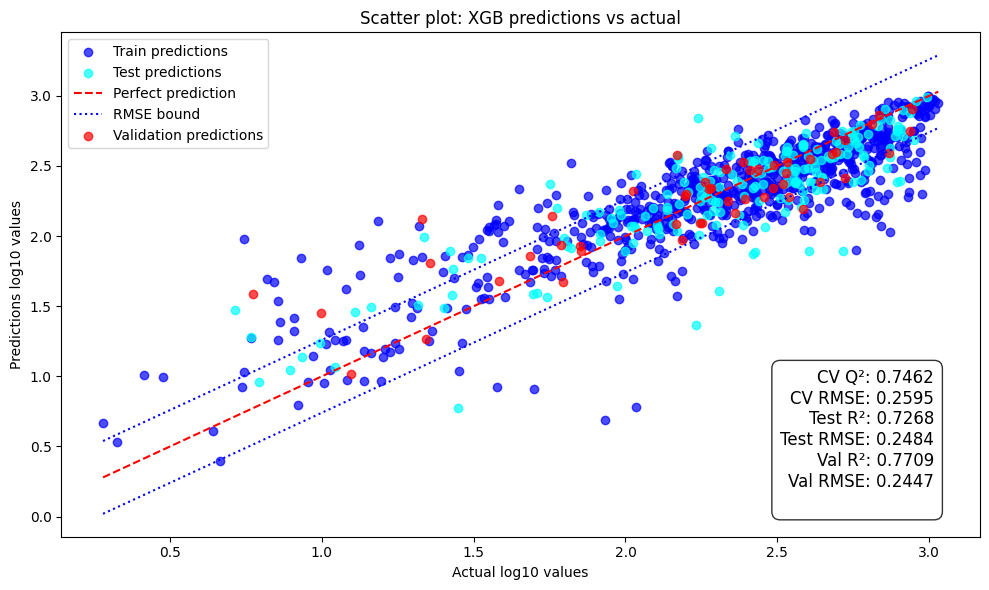

Training GradientBoosting...
GradientBoosting - RMSE (CV): 0.2703, Q² (CV): 0.7265, MAE (CV): 0.1916
GradientBoosting - Validation RMSE: 0.2462, Validation R²: 0.7680, Validation MAE: 0.1735
GradientBoosting - Test RMSE: 0.2712, Test R²: 0.6744, Test MAE: 0.1882
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 0.2504613033317137, 3.035354555358806
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.0225005056425505, 2.90363467271693
Min/Max y_test: 0.712456041114732, 2.9922494242869937
Min/Max y_test_pred: 0.8923788043494065, 3.0068783963056456


C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:106: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line + avg_rmse, 'b--', label=f'RMSE bound', linestyle=':')
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:107: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line - avg_rmse, 'b--', linestyle=':')


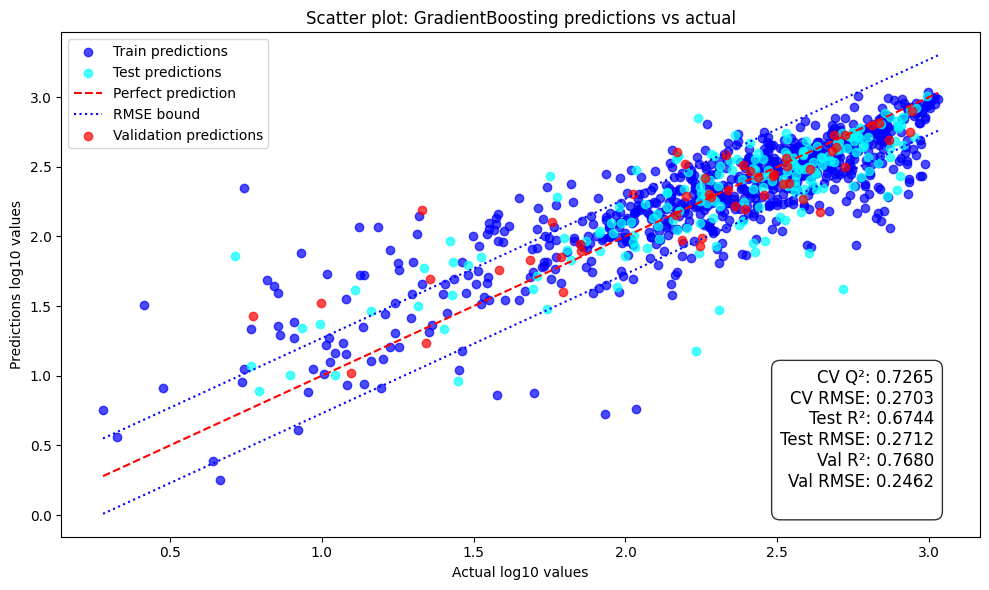

Training HistGradientBoosting...
HistGradientBoosting - RMSE (CV): 0.2773, Q² (CV): 0.7112, MAE (CV): 0.1995
HistGradientBoosting - Validation RMSE: 0.2884, Validation R²: 0.6817, Validation MAE: 0.1954
HistGradientBoosting - Test RMSE: 0.2634, Test R²: 0.6929, Test MAE: 0.1938
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 0.35548497896398906, 3.1157625664977258
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 0.9835961789437613, 2.821478568696628
Min/Max y_test: 0.712456041114732, 2.9922494242869937
Min/Max y_test_pred: 0.9818072636558464, 2.998843510548302


C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:106: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line + avg_rmse, 'b--', label=f'RMSE bound', linestyle=':')
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:107: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line - avg_rmse, 'b--', linestyle=':')


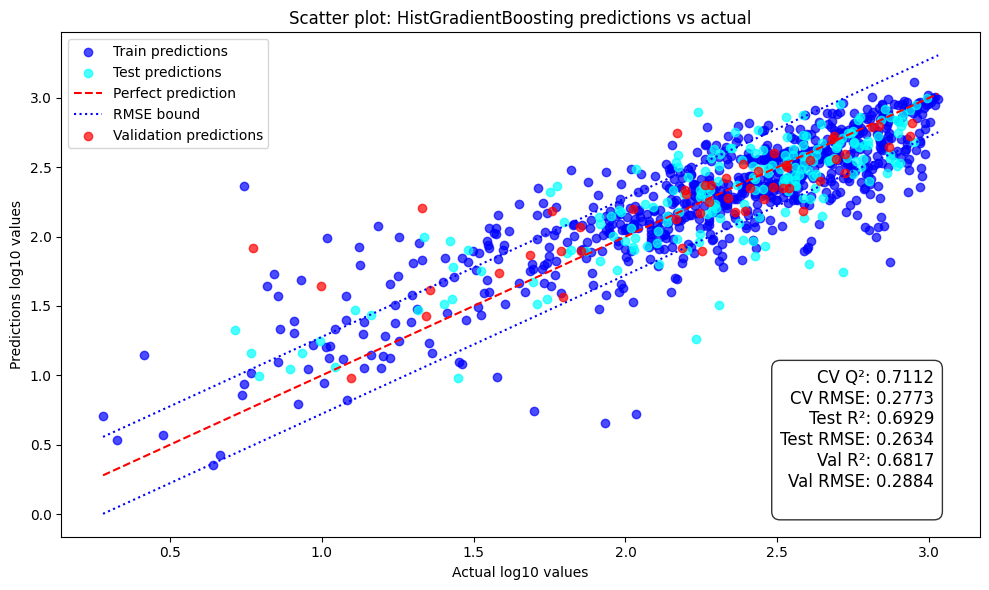

Training LGBM...
LGBM - RMSE (CV): 0.2654, Q² (CV): 0.7360, MAE (CV): 0.1931
LGBM - Validation RMSE: 0.2850, Validation R²: 0.6893, Validation MAE: 0.1886
LGBM - Test RMSE: 0.2549, Test R²: 0.7123, Test MAE: 0.1834
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 0.3902260055362825, 3.021578976139531
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 0.9424456736623207, 2.8770255143978956
Min/Max y_test: 0.712456041114732, 2.9922494242869937
Min/Max y_test_pred: 0.9238359562529211, 3.003194839388977


C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:106: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line + avg_rmse, 'b--', label=f'RMSE bound', linestyle=':')
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\1966603828.py:107: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(ideal_line, ideal_line - avg_rmse, 'b--', linestyle=':')


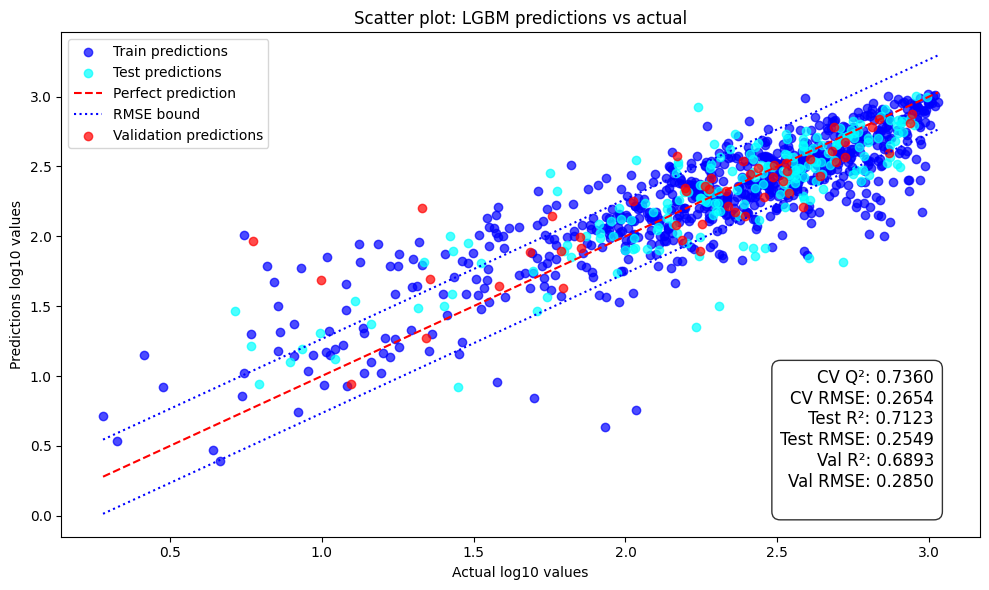

In [7]:
# Cross-validation with KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=1984)

# Dictionary to store MAE values for all models
mae_results = {}

# Model cycle
for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Metric storage arrays
    mse_scores = []
    rmse_scores = []
    q2_scores = []
    mae_scores = []  # Array for MAE during cross-validation

    # Model learning and prediction
    y_pred_list = []
    y_true_list = []

    # Cross-validation cycle
    for train_index, test_index in kf.split(X_train_scaled):
        X_train_fold, X_test_fold = X_train_scaled[train_index], X_train_scaled[test_index]
        y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]

        # Model training in current fold
        model.fit(X_train_fold, y_train_fold)

        # Prediction on test set (fold)
        y_pred = model.predict(X_test_fold)

        # Preserving predictions and true values
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_test_fold)

        # Calculating fold metrics
        mse = mean_squared_error(y_test_fold, y_pred)
        rmse = np.sqrt(mse)
        q2 = r2_score(y_test_fold, y_pred)
        mae = mean_absolute_error(y_test_fold, y_pred)  # Calculate MAE

        mse_scores.append(mse)
        rmse_scores.append(rmse)
        q2_scores.append(q2)
        mae_scores.append(mae)  # Store MAE for each fold

    # Cross-validation metric averages
    avg_mse = np.mean(mse_scores)
    avg_rmse = np.mean(rmse_scores)
    avg_q2 = np.mean(q2_scores)
    avg_mae = np.mean(mae_scores)  # Average MAE

    # Validation on separate dataset
    y_val_pred = model.predict(X_val_scaled)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val, y_val_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)  # Calculate MAE for validation

    # Test on common training set
    model.fit(X_train_scaled, y_train)  # Learning on the whole training set
    y_test_pred = model.predict(X_test_scaled)
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)  # Calculate MAE for test

    # Output metric values
    print(f"{model_name} - RMSE (CV): {avg_rmse:.4f}, Q² (CV): {avg_q2:.4f}, MAE (CV): {avg_mae:.4f}")
    print(f"{model_name} - Validation RMSE: {val_rmse:.4f}, Validation R²: {val_r2:.4f}, Validation MAE: {val_mae:.4f}")
    print(f"{model_name} - Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}, Test MAE: {test_mae:.4f}")

    # Store MAE results for this model
    mae_results[model_name] = {
        'Train MAE (CV)': avg_mae,
        'Validation MAE': val_mae,
        'Test MAE': test_mae
    }

    # Visualization of predictions on the graph
    fig, ax = plt.subplots(figsize=(10, 6))

    # List content check
    print(f"y_true_list length: {len(y_true_list)}, y_pred_list length: {len(y_pred_list)}")
    print(f"y_val length: {len(y_val)}, y_val_pred length: {len(y_val_pred)}")
    print(f"y_test length: {len(y_test)}, y_test_pred length: {len(y_test_pred)}")

    # Checking minimum and maximum values
    print(f"Min/Max y_true_list: {min(y_true_list)}, {max(y_true_list)}")
    print(f"Min/Max y_pred_list: {min(y_pred_list)}, {max(y_pred_list)}")
    print(f"Min/Max y_val: {min(y_val)}, {max(y_val)}")
    print(f"Min/Max y_val_pred: {min(y_val_pred)}, {max(y_val_pred)}")
    print(f"Min/Max y_test: {min(y_test)}, {max(y_test)}")
    print(f"Min/Max y_test_pred: {min(y_test_pred)}, {max(y_test_pred)}")

    # charting
    if len(y_true_list) > 0 and len(y_pred_list) > 0:  # Check that the lists are not empty
        ax.scatter(y_true_list, y_pred_list, alpha=0.7, color='blue', label='Train predictions')
    if len(y_test) > 0 and len(y_test_pred) > 0:  # Check that the lists are not empty
        ax.scatter(y_test, y_test_pred, alpha=0.7, color='cyan', label='Test predictions')

    # Boundary RMSE drawing
    ideal_line = np.linspace(min(y_true_list), max(y_true_list), 100)
    ax.plot(ideal_line, ideal_line, 'r--', label='Perfect prediction')
    ax.plot(ideal_line, ideal_line + avg_rmse, 'b--', label=f'RMSE bound', linestyle=':')
    ax.plot(ideal_line, ideal_line - avg_rmse, 'b--', linestyle=':')

    if len(y_val) > 0 and len(y_val_pred) > 0:  # Check that the lists are not empty
        ax.scatter(y_val, y_val_pred, alpha=0.7, color='red', label='Validation predictions')

    # Adding metrics to the chart
    metrics_text = (
        f"CV Q²: {avg_q2:.4f}\n"
        f"CV RMSE: {avg_rmse:.4f}\n"
        f"Test R²: {test_r2:.4f}\n"
        f"Test RMSE: {test_rmse:.4f}\n"
        f"Val R²: {val_r2:.4f}\n"
        f"Val RMSE: {val_rmse:.4f}\n"
    )
    ax.text(0.95, 0.05, metrics_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5', edgecolor='black'))

    # Graphics customization
    ax.set_title(f'Scatter plot: {model_name} predictions vs actual')
    ax.set_xlabel('Actual log10 values')
    ax.set_ylabel('Predictions log10 values')
    ax.legend()
    plt.tight_layout()
    plt.show()

GROUPKFOLD


DATASET INFORMATION
------------------------------------------------------------
Training rows: 732
Validation rows: 51
Test rows: 196
Training group labels: 732
Validation group labels: 51
Test group labels: 196
Unique material groups in training: 183
Unique material groups in validation: 39
Unique material groups in test: 91


Training Bagging...
Fold 1: 585 train rows, 147 test rows, 147 train groups, 36 test groups
Fold 2: 585 train rows, 147 test rows, 146 train groups, 37 test groups
Fold 3: 586 train rows, 146 test rows, 147 train groups, 36 test groups
Fold 4: 586 train rows, 146 test rows, 146 train groups, 37 test groups
Fold 5: 586 train rows, 146 test rows, 146 train groups, 37 test groups
Bagging - RMSE (Group CV): 0.4847, Q² (Group CV): 0.0447, MAE (Group CV): 0.3664
Bagging - Validation RMSE: 0.3226, Validation R²: 0.6019, Validation MAE: 0.2050
Bagging - Test R²: 0.7473, Test RMSE: 0.2389, Test MAE: 0.1720
y_true_list length: 732, y_pred_list length: 732
y_val length: 

C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:738: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:746: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(


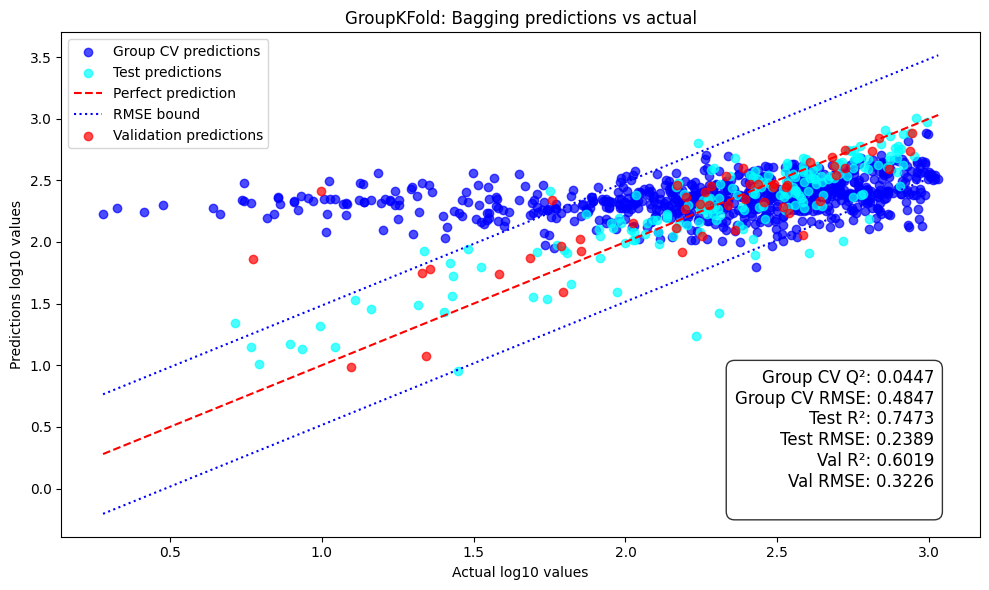



Training ExtraTrees...
Fold 1: 585 train rows, 147 test rows, 147 train groups, 36 test groups
Fold 2: 585 train rows, 147 test rows, 146 train groups, 37 test groups
Fold 3: 586 train rows, 146 test rows, 147 train groups, 36 test groups
Fold 4: 586 train rows, 146 test rows, 146 train groups, 37 test groups
Fold 5: 586 train rows, 146 test rows, 146 train groups, 37 test groups
ExtraTrees - RMSE (Group CV): 0.4902, Q² (Group CV): 0.0044, MAE (Group CV): 0.3618
ExtraTrees - Validation RMSE: 0.3369, Validation R²: 0.5656, Validation MAE: 0.2052
ExtraTrees - Test R²: 0.7490, Test RMSE: 0.2381, Test MAE: 0.1704
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 1.2255766692213652, 2.9062502103099566
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.1045735608584832, 2.933716914186461
Min/Max y_test: 0

C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:738: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:746: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(


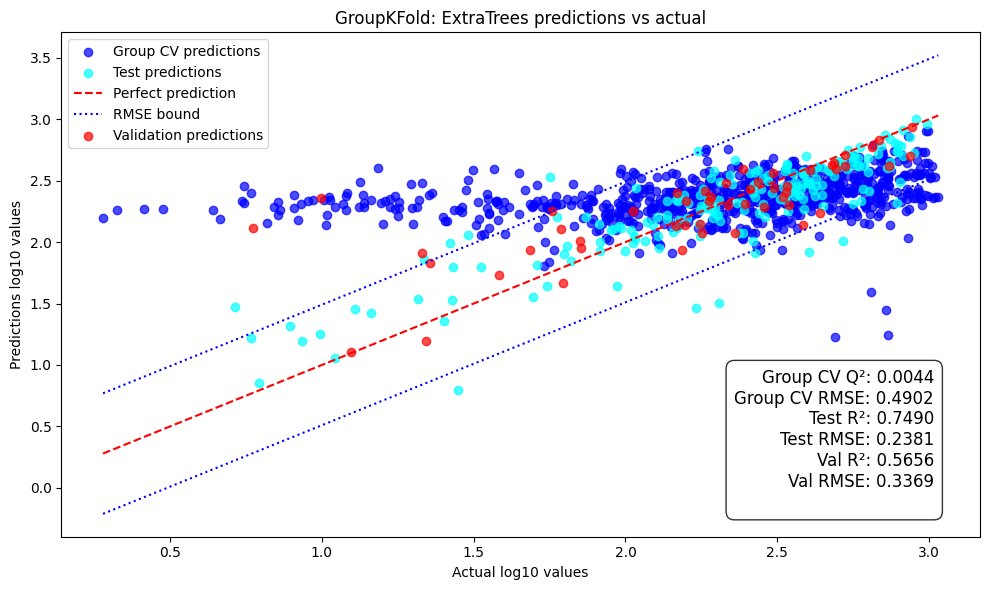



Training RandomForest...
Fold 1: 585 train rows, 147 test rows, 147 train groups, 36 test groups
Fold 2: 585 train rows, 147 test rows, 146 train groups, 37 test groups
Fold 3: 586 train rows, 146 test rows, 147 train groups, 36 test groups
Fold 4: 586 train rows, 146 test rows, 146 train groups, 37 test groups
Fold 5: 586 train rows, 146 test rows, 146 train groups, 37 test groups
RandomForest - RMSE (Group CV): 0.4716, Q² (Group CV): 0.1005, MAE (Group CV): 0.3558
RandomForest - Validation RMSE: 0.3195, Validation R²: 0.6094, Validation MAE: 0.2023
RandomForest - Test R²: 0.7336, Test RMSE: 0.2453, Test MAE: 0.1807
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 1.8955902686276753, 2.890885863443019
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.0302003626710297, 2.9244992625876876
Min/Max y

C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:738: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:746: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(


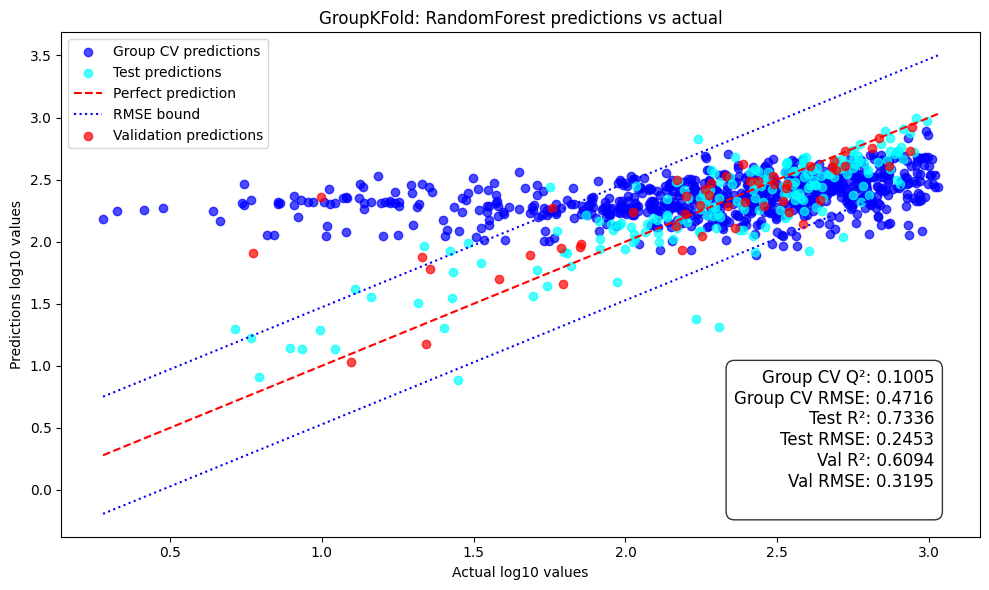



Training XGB...
Fold 1: 585 train rows, 147 test rows, 147 train groups, 36 test groups
Fold 2: 585 train rows, 147 test rows, 146 train groups, 37 test groups
Fold 3: 586 train rows, 146 test rows, 147 train groups, 36 test groups
Fold 4: 586 train rows, 146 test rows, 146 train groups, 37 test groups
Fold 5: 586 train rows, 146 test rows, 146 train groups, 37 test groups
XGB - RMSE (Group CV): 0.4646, Q² (Group CV): 0.1269, MAE (Group CV): 0.3504
XGB - Validation RMSE: 0.3414, Validation R²: 0.5541, Validation MAE: 0.2020
XGB - Test R²: 0.7268, Test RMSE: 0.2484, Test MAE: 0.1812
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 1.8327120542526245, 2.9213948249816895
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.0314176082611084, 2.903968334197998
Min/Max y_test: 0.712456041114732, 2.99224942

C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:738: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:746: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(


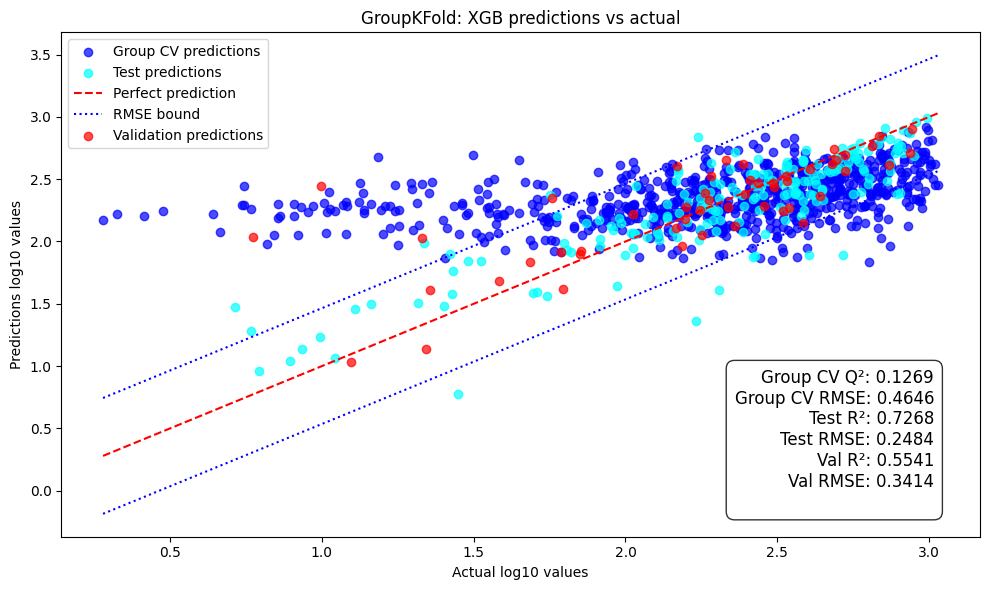



Training GradientBoosting...
Fold 1: 585 train rows, 147 test rows, 147 train groups, 36 test groups
Fold 2: 585 train rows, 147 test rows, 146 train groups, 37 test groups
Fold 3: 586 train rows, 146 test rows, 147 train groups, 36 test groups
Fold 4: 586 train rows, 146 test rows, 146 train groups, 37 test groups
Fold 5: 586 train rows, 146 test rows, 146 train groups, 37 test groups
GradientBoosting - RMSE (Group CV): 0.4609, Q² (Group CV): 0.1380, MAE (Group CV): 0.3480
GradientBoosting - Validation RMSE: 0.3202, Validation R²: 0.6077, Validation MAE: 0.2037
GradientBoosting - Test R²: 0.6744, Test RMSE: 0.2712, Test MAE: 0.1882
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 1.55931664543102, 2.994009343979915
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.0987710861820505, 2.902343797425

C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:738: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:746: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(


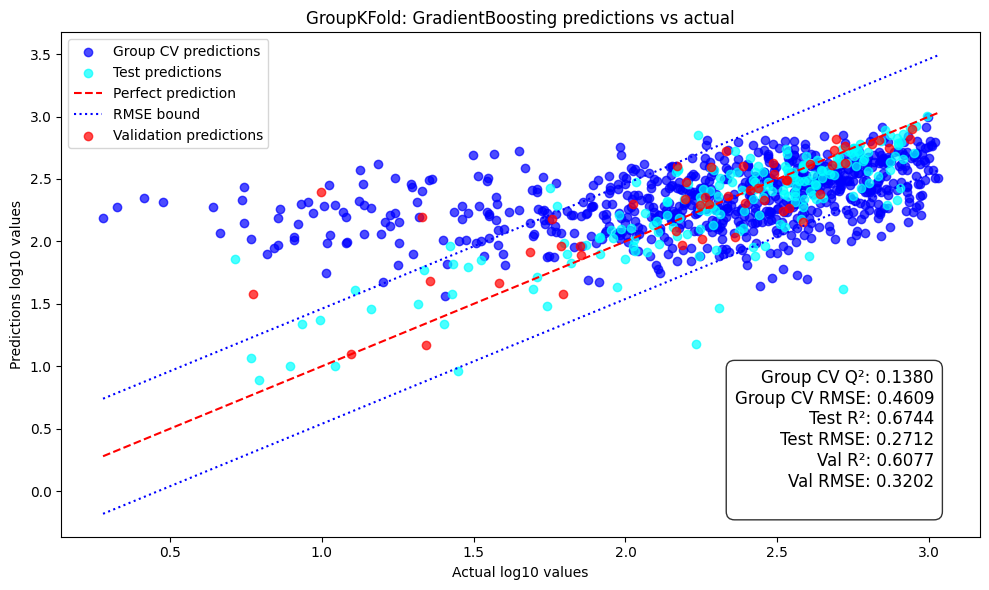



Training HistGradientBoosting...
Fold 1: 585 train rows, 147 test rows, 147 train groups, 36 test groups
Fold 2: 585 train rows, 147 test rows, 146 train groups, 37 test groups
Fold 3: 586 train rows, 146 test rows, 147 train groups, 36 test groups
Fold 4: 586 train rows, 146 test rows, 146 train groups, 37 test groups
Fold 5: 586 train rows, 146 test rows, 146 train groups, 37 test groups
HistGradientBoosting - RMSE (Group CV): 0.4930, Q² (Group CV): 0.0121, MAE (Group CV): 0.3726
HistGradientBoosting - Validation RMSE: 0.3681, Validation R²: 0.4817, Validation MAE: 0.2114
HistGradientBoosting - Test R²: 0.6929, Test RMSE: 0.2634, Test MAE: 0.1938
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 1.4674577393227348, 3.009045161919334
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.03900452234095

C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:738: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:746: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(


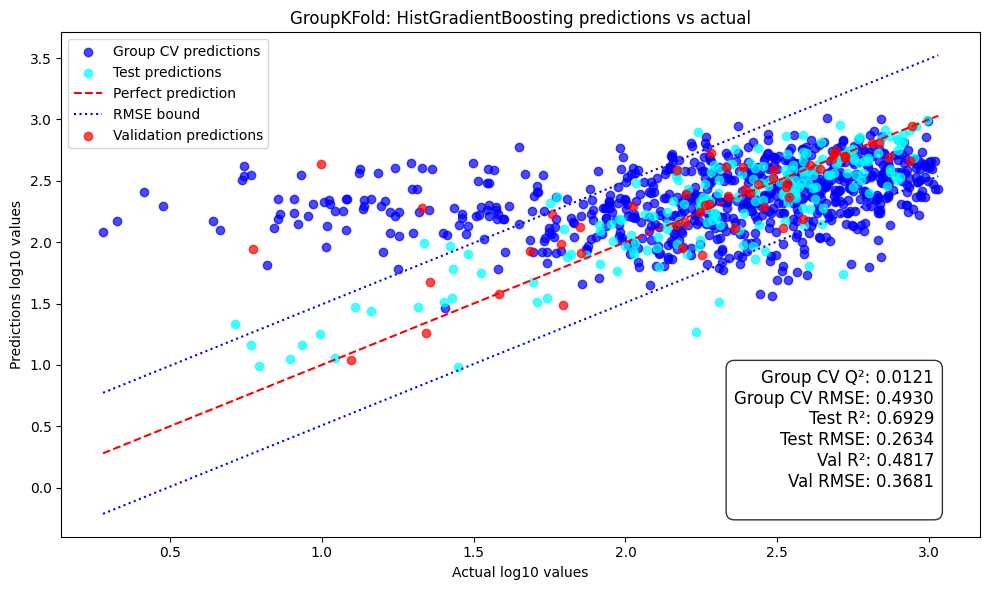



Training LGBM...
Fold 1: 585 train rows, 147 test rows, 147 train groups, 36 test groups
Fold 2: 585 train rows, 147 test rows, 146 train groups, 37 test groups
Fold 3: 586 train rows, 146 test rows, 147 train groups, 36 test groups
Fold 4: 586 train rows, 146 test rows, 146 train groups, 37 test groups
Fold 5: 586 train rows, 146 test rows, 146 train groups, 37 test groups
LGBM - RMSE (Group CV): 0.4782, Q² (Group CV): 0.0757, MAE (Group CV): 0.3631
LGBM - Validation RMSE: 0.3763, Validation R²: 0.4583, Validation MAE: 0.2208
LGBM - Test R²: 0.7123, Test RMSE: 0.2549, Test MAE: 0.1834
y_true_list length: 732, y_pred_list length: 732
y_val length: 51, y_val_pred length: 51
y_test length: 196, y_test_pred length: 196
Min/Max y_true_list: 0.2795200547766169, 3.0299039100673495
Min/Max y_pred_list: 1.644915488724343, 2.962578794204653
Min/Max y_val: 0.774409952228979, 2.9447191021401102
Min/Max y_val_pred: 1.0469486067954565, 2.951005658377759
Min/Max y_test: 0.712456041114732, 2.992249

C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:738: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(
C:\Users\Sand\AppData\Local\Temp\ipykernel_19452\3921729007.py:746: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(


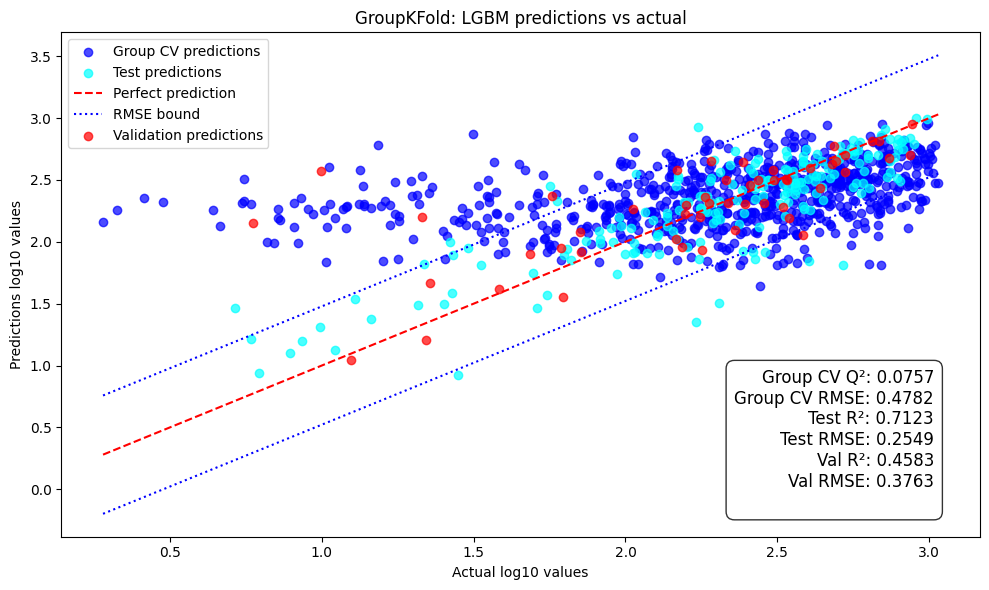

In [8]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    BaggingRegressor,
    ExtraTreesRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv('data/final_data_exchange_bias.csv')

core = df['core'].copy()
shell = df['shell'].copy()
formula = df['formula'].copy()

df = df.drop(columns=['core', 'shell', 'formula'])


# ============================================================
# PREPROCESSING
# ============================================================

# Target
y = df['exc_bias_oe']

# Keep only positive target values
positive_mask = y > 0

y = y[positive_mask]

# Keep material identity aligned with retained rows
core = core[positive_mask].reset_index(drop=True)
shell = shell[positive_mask].reset_index(drop=True)
formula = formula[positive_mask].reset_index(drop=True)

# ------------------------------------------------------------
# MATERIAL GROUP
# ------------------------------------------------------------
# Same core + shell composition = same material group
#
# This is used ONLY by GroupKFold.
# It does not remove or average any observations.
# ------------------------------------------------------------

groups = (
    core.astype(str)
    + "||"
    + shell.astype(str)
)


# ============================================================
# TARGET SMOOTHING
# ============================================================

y_smooth = gaussian_filter1d(
    y,
    sigma=2
)

# Logarithmic transformation
y_log = np.log10(y_smooth)


# ============================================================
# FEATURE GENERATION
# ============================================================

X = df[positive_mask].drop(
    columns=['exc_bias_oe']
)


# ============================================================
# KNN IMPUTATION
# ============================================================

knn_imputer = KNNImputer(
    n_neighbors=5
)

X_imputed = knn_imputer.fit_transform(X)


# ============================================================
# TRAIN / TEST SPLIT
#
# Same split as original code.
# Group labels are carried along with the rows.
# ============================================================

X_train, X_test, y_train, y_test, groups_train, groups_test = \
    train_test_split(
        X_imputed,
        y_log,
        groups,
        test_size=0.2,
        random_state=1984
    )


# ============================================================
# TRAIN / VALIDATION SPLIT
#
# Same split as original code.
# Group labels are again carried along.
# ============================================================

X_train, X_val, y_train, y_val, groups_train, groups_val = \
    train_test_split(
        X_train,
        y_train,
        groups_train,
        test_size=0.0639,
        random_state=1984
    )


# ============================================================
# SCALING
# ============================================================

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# CHECK GROUP ALIGNMENT
# ============================================================

print("\nDATASET INFORMATION")
print("-" * 60)

print("Training rows:",
      len(X_train_scaled))

print("Validation rows:",
      len(X_val_scaled))

print("Test rows:",
      len(X_test_scaled))

print("Training group labels:",
      len(groups_train))

print("Validation group labels:",
      len(groups_val))

print("Test group labels:",
      len(groups_test))

print("Unique material groups in training:",
      groups_train.nunique())

print("Unique material groups in validation:",
      groups_val.nunique())

print("Unique material groups in test:",
      groups_test.nunique())

assert len(X_train_scaled) == len(groups_train), \
    "Training rows and group labels are not aligned."

assert len(X_val_scaled) == len(groups_val), \
    "Validation rows and group labels are not aligned."

assert len(X_test_scaled) == len(groups_test), \
    "Test rows and group labels are not aligned."


# ============================================================
# MODELS
#
# EXACTLY AS IN ORIGINAL GITHUB CODE
# ============================================================

models = {

    'Bagging': BaggingRegressor(
        n_estimators=300,
        max_samples=0.9776911085655549,
        max_features=0.31309603223233823,
        bootstrap=False,
        random_state=1984
    ),

    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=348,
        max_depth=76,
        min_samples_split=2,
        min_samples_leaf=2,
        bootstrap=False,
        max_features=None,
        ccp_alpha=0,
        random_state=1984
    ),

    'RandomForest': RandomForestRegressor(
        n_estimators=384,
        max_depth=65,
        min_samples_split=3,
        min_samples_leaf=2,
        bootstrap=False,
        max_features='log2',
        random_state=1984
    ),

    'XGB': XGBRegressor(
        n_estimators=424,
        max_depth=22,
        learning_rate=0.029775486467142665,
        subsample=0.7358573421632647,
        colsample_bytree=0.5128835927539236,
        gamma=0.001178216687382395,
        reg_alpha=0.3688362981967942,
        reg_lambda=0.9581849266893232,
        min_child_weight=4,
        scale_pos_weight=9.787498596663324,
        random_state=1984
    ),

    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=450,
        max_depth=39,
        learning_rate=0.03325774896721734,
        subsample=0.5249255381726716,
        min_samples_split=18,
        min_samples_leaf=3,
        random_state=1984
    ),

    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=466,
        max_depth=22,
        learning_rate=0.11068107159769078,
        max_leaf_nodes=87,
        min_samples_leaf=35,
        random_state=1984
    ),

    'LGBM': LGBMRegressor(
        n_estimators=410,
        max_depth=27,
        learning_rate=0.06189087491958441,
        num_leaves=60,
        min_data_in_leaf=22,
        feature_fraction=0.5107580106941778,
        scale_pos_weight=19.965009642913554,
        reg_alpha=0.061407641972931915,
        reg_lambda=0.5275644028683729,
        bagging_fraction=0.8938154558415361,
        bagging_freq=4,
        random_state=1984,
        verbose=-1
    ),
}


# ============================================================
# GROUPKFold
#
# ONLY CHANGE FROM ORIGINAL:
#
# KFold(...)
#       ↓
# GroupKFold(...)
#
# Groups = core + shell composition
# ============================================================

gkf = GroupKFold(
    n_splits=5
)


# ============================================================
# STORE MAE RESULTS
# ============================================================

mae_results = {}


# ============================================================
# MODEL CYCLE
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("=" * 70)
    print(f"Training {model_name}...")
    print("=" * 70)

    # Metric storage arrays
    mse_scores = []
    rmse_scores = []
    q2_scores = []
    mae_scores = []

    # Prediction storage
    y_pred_list = []
    y_true_list = []


    # ========================================================
    # GROUP CROSS-VALIDATION
    # ========================================================

    for fold, (train_index, test_index) in enumerate(
        gkf.split(
            X_train_scaled,
            y_train,
            groups=groups_train
        ),
        start=1
    ):

        # Fold data
        X_train_fold = X_train_scaled[
            train_index
        ]

        X_test_fold = X_train_scaled[
            test_index
        ]

        y_train_fold = y_train[
            train_index
        ]

        y_test_fold = y_train[
            test_index
        ]

        # ----------------------------------------------------
        # CHECK GROUP SEPARATION
        # ----------------------------------------------------

        train_groups = set(
            groups_train.iloc[train_index]
        )

        test_groups = set(
            groups_train.iloc[test_index]
        )

        overlap = train_groups.intersection(
            test_groups
        )

        assert len(overlap) == 0, (
            f"GROUP LEAKAGE in fold {fold}: "
            f"{overlap}"
        )

        print(
            f"Fold {fold}: "
            f"{len(train_index)} train rows, "
            f"{len(test_index)} test rows, "
            f"{len(train_groups)} train groups, "
            f"{len(test_groups)} test groups"
        )


        # ----------------------------------------------------
        # MODEL FIT
        # ----------------------------------------------------

        model.fit(
            X_train_fold,
            y_train_fold
        )


        # ----------------------------------------------------
        # PREDICTION
        # ----------------------------------------------------

        y_pred = model.predict(
            X_test_fold
        )


        # ----------------------------------------------------
        # STORE PREDICTIONS
        # ----------------------------------------------------

        y_pred_list.extend(
            y_pred
        )

        y_true_list.extend(
            y_test_fold
        )


        # ----------------------------------------------------
        # FOLD METRICS
        # ----------------------------------------------------

        mse = mean_squared_error(
            y_test_fold,
            y_pred
        )

        rmse = np.sqrt(
            mse
        )

        q2 = r2_score(
            y_test_fold,
            y_pred
        )

        mae = mean_absolute_error(
            y_test_fold,
            y_pred
        )


        mse_scores.append(
            mse
        )

        rmse_scores.append(
            rmse
        )

        q2_scores.append(
            q2
        )

        mae_scores.append(
            mae
        )


    # ========================================================
    # GROUP CV METRIC AVERAGES
    # ========================================================

    avg_mse = np.mean(
        mse_scores
    )

    avg_rmse = np.mean(
        rmse_scores
    )

    avg_q2 = np.mean(
        q2_scores
    )

    avg_mae = np.mean(
        mae_scores
    )


    # ========================================================
    # VALIDATION
    #
    # SAME AS ORIGINAL CODE
    #
    # The model at this point is the model trained on the
    # LAST GroupKFold training fold.
    # ========================================================

    y_val_pred = model.predict(
        X_val_scaled
    )

    val_mse = mean_squared_error(
        y_val,
        y_val_pred
    )

    val_rmse = np.sqrt(
        val_mse
    )

    val_r2 = r2_score(
        y_val,
        y_val_pred
    )

    val_mae = mean_absolute_error(
        y_val,
        y_val_pred
    )


    # ========================================================
    # TEST
    #
    # SAME AS ORIGINAL CODE
    #
    # Refit on complete X_train.
    # ========================================================

    model.fit(
        X_train_scaled,
        y_train
    )

    y_test_pred = model.predict(
        X_test_scaled
    )

    test_r2 = r2_score(
        y_test,
        y_test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred
        )
    )

    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )


    # ========================================================
    # OUTPUT
    # ========================================================

    print(
        f"{model_name} - "
        f"RMSE (Group CV): {avg_rmse:.4f}, "
        f"Q² (Group CV): {avg_q2:.4f}, "
        f"MAE (Group CV): {avg_mae:.4f}"
    )

    print(
        f"{model_name} - "
        f"Validation RMSE: {val_rmse:.4f}, "
        f"Validation R²: {val_r2:.4f}, "
        f"Validation MAE: {val_mae:.4f}"
    )

    print(
        f"{model_name} - "
        f"Test R²: {test_r2:.4f}, "
        f"Test RMSE: {test_rmse:.4f}, "
        f"Test MAE: {test_mae:.4f}"
    )


    # ========================================================
    # STORE MAE
    # ========================================================

    mae_results[model_name] = {

        'Group CV MAE': avg_mae,

        'Validation MAE': val_mae,

        'Test MAE': test_mae
    }


    # ========================================================
    # PLOT
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    # --------------------------------------------------------
    # LENGTH CHECKS
    # --------------------------------------------------------

    print(
        f"y_true_list length: "
        f"{len(y_true_list)}, "
        f"y_pred_list length: "
        f"{len(y_pred_list)}"
    )

    print(
        f"y_val length: "
        f"{len(y_val)}, "
        f"y_val_pred length: "
        f"{len(y_val_pred)}"
    )

    print(
        f"y_test length: "
        f"{len(y_test)}, "
        f"y_test_pred length: "
        f"{len(y_test_pred)}"
    )


    # --------------------------------------------------------
    # MIN / MAX CHECKS
    # --------------------------------------------------------

    print(
        f"Min/Max y_true_list: "
        f"{min(y_true_list)}, "
        f"{max(y_true_list)}"
    )

    print(
        f"Min/Max y_pred_list: "
        f"{min(y_pred_list)}, "
        f"{max(y_pred_list)}"
    )

    print(
        f"Min/Max y_val: "
        f"{min(y_val)}, "
        f"{max(y_val)}"
    )

    print(
        f"Min/Max y_val_pred: "
        f"{min(y_val_pred)}, "
        f"{max(y_val_pred)}"
    )

    print(
        f"Min/Max y_test: "
        f"{min(y_test)}, "
        f"{max(y_test)}"
    )

    print(
        f"Min/Max y_test_pred: "
        f"{min(y_test_pred)}, "
        f"{max(y_test_pred)}"
    )


    # --------------------------------------------------------
    # GROUP CV PREDICTIONS
    # --------------------------------------------------------

    if (
        len(y_true_list) > 0
        and len(y_pred_list) > 0
    ):

        ax.scatter(
            y_true_list,
            y_pred_list,
            alpha=0.7,
            color='blue',
            label='Group CV predictions'
        )


    # --------------------------------------------------------
    # TEST PREDICTIONS
    # --------------------------------------------------------

    if (
        len(y_test) > 0
        and len(y_test_pred) > 0
    ):

        ax.scatter(
            y_test,
            y_test_pred,
            alpha=0.7,
            color='cyan',
            label='Test predictions'
        )


    # --------------------------------------------------------
    # PERFECT PREDICTION LINE
    # --------------------------------------------------------

    ideal_line = np.linspace(
        min(y_true_list),
        max(y_true_list),
        100
    )

    ax.plot(
        ideal_line,
        ideal_line,
        'r--',
        label='Perfect prediction'
    )


    # --------------------------------------------------------
    # RMSE BOUNDS
    # --------------------------------------------------------

    ax.plot(
        ideal_line,
        ideal_line + avg_rmse,
        'b--',
        label='RMSE bound',
        linestyle=':'
    )

    ax.plot(
        ideal_line,
        ideal_line - avg_rmse,
        'b--',
        linestyle=':'
    )


    # --------------------------------------------------------
    # VALIDATION PREDICTIONS
    # --------------------------------------------------------

    if (
        len(y_val) > 0
        and len(y_val_pred) > 0
    ):

        ax.scatter(
            y_val,
            y_val_pred,
            alpha=0.7,
            color='red',
            label='Validation predictions'
        )


    # --------------------------------------------------------
    # METRICS TEXT
    # --------------------------------------------------------

    metrics_text = (

        f"Group CV Q²: "
        f"{avg_q2:.4f}\n"

        f"Group CV RMSE: "
        f"{avg_rmse:.4f}\n"

        f"Test R²: "
        f"{test_r2:.4f}\n"

        f"Test RMSE: "
        f"{test_rmse:.4f}\n"

        f"Val R²: "
        f"{val_r2:.4f}\n"

        f"Val RMSE: "
        f"{val_rmse:.4f}\n"
    )


    ax.text(
        0.95,
        0.05,
        metrics_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.8,
            boxstyle='round,pad=0.5',
            edgecolor='black'
        )
    )


    # --------------------------------------------------------
    # GRAPH FORMATTING
    # --------------------------------------------------------

    ax.set_title(
        f'GroupKFold: '
        f'{model_name} predictions vs actual'
    )

    ax.set_xlabel(
        'Actual log10 values'
    )

    ax.set_ylabel(
        'Predictions log10 values'
    )

    ax.legend()

    plt.tight_layout()

    plt.show()

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv('data/final_data_exchange_bias.csv')

# Keep formula and target together
data = df[['formula', 'exc_bias_oe']].copy()

# ============================================================
# SAME FILTER AS KAPRANOVA
# ============================================================

data = data[data['exc_bias_oe'] > 0].reset_index(drop=True)

# ============================================================
# CREATE THE THREE SPLITS EXACTLY AS THEIR CODE
# ============================================================

train_val, test = train_test_split(
    data,
    test_size=0.2,
    random_state=1984
)

train, validation = train_test_split(
    train_val,
    test_size=0.0639,
    random_state=1984
)

# ============================================================
# UNIQUE FORMULA SETS
# ============================================================

train_formulas = set(train['formula'].astype(str))
val_formulas   = set(validation['formula'].astype(str))
test_formulas  = set(test['formula'].astype(str))


# ============================================================
# BASIC INFORMATION
# ============================================================

print("=" * 70)
print("DATASET / SPLIT INFORMATION")
print("=" * 70)

print(f"Total positive rows : {len(data)}")
print(f"Training rows       : {len(train)}")
print(f"Validation rows     : {len(validation)}")
print(f"Test rows           : {len(test)}")

print()

print(f"Unique training formulas   : {len(train_formulas)}")
print(f"Unique validation formulas : {len(val_formulas)}")
print(f"Unique test formulas       : {len(test_formulas)}")


# ============================================================
# PAIRWISE OVERLAPS
# ============================================================

train_val_overlap = train_formulas & val_formulas
train_test_overlap = train_formulas & test_formulas
val_test_overlap = val_formulas & test_formulas

print("\n" + "=" * 70)
print("PAIRWISE FORMULA OVERLAP")
print("=" * 70)

print(
    f"Training ∩ Validation : "
    f"{len(train_val_overlap)} / {len(val_formulas)} "
    f"validation formulas"
)

print(
    f"Training ∩ Test       : "
    f"{len(train_test_overlap)} / {len(test_formulas)} "
    f"test formulas"
)

print(
    f"Validation ∩ Test     : "
    f"{len(val_test_overlap)} / {len(val_formulas)} "
    f"validation formulas"
)


# ============================================================
# THREE-WAY OVERLAP
# ============================================================

all_three = (
    train_formulas
    & val_formulas
    & test_formulas
)

print("\n" + "=" * 70)
print("THREE-WAY OVERLAP")
print("=" * 70)

print(
    f"Formulas appearing in ALL THREE sets: "
    f"{len(all_three)}"
)


# ============================================================
# FORMULAS UNIQUE TO EACH SPLIT
# ============================================================

train_only = (
    train_formulas
    - val_formulas
    - test_formulas
)

val_only = (
    val_formulas
    - train_formulas
    - test_formulas
)

test_only = (
    test_formulas
    - train_formulas
    - val_formulas
)

print("\n" + "=" * 70)
print("FORMULAS UNIQUE TO ONE SPLIT")
print("=" * 70)

print(f"Training only   : {len(train_only)}")
print(f"Validation only : {len(val_only)}")
print(f"Test only       : {len(test_only)}")


# ============================================================
# TWO-WAY ONLY
# ============================================================

train_val_only = (
    train_formulas
    & val_formulas
    - test_formulas
)

train_test_only = (
    train_formulas
    & test_formulas
    - val_formulas
)

val_test_only = (
    val_formulas
    & test_formulas
    - train_formulas
)

print("\n" + "=" * 70)
print("FORMULAS APPEARING IN EXACTLY TWO SETS")
print("=" * 70)

print(f"Training + Validation only : {len(train_val_only)}")
print(f"Training + Test only       : {len(train_test_only)}")
print(f"Validation + Test only     : {len(val_test_only)}")


# ============================================================
# DETAILED FORMULA OCCURRENCE TABLE
# ============================================================

all_formulas = sorted(
    train_formulas
    | val_formulas
    | test_formulas
)

overlap_table = pd.DataFrame({
    'formula': all_formulas
})

overlap_table['training'] = (
    overlap_table['formula'].isin(train_formulas)
)

overlap_table['validation'] = (
    overlap_table['formula'].isin(val_formulas)
)

overlap_table['test'] = (
    overlap_table['formula'].isin(test_formulas)
)

# Number of rows of each formula in each split
train_counts = train['formula'].value_counts()
val_counts = validation['formula'].value_counts()
test_counts = test['formula'].value_counts()

overlap_table['training_rows'] = (
    overlap_table['formula'].map(train_counts).fillna(0).astype(int)
)

overlap_table['validation_rows'] = (
    overlap_table['formula'].map(val_counts).fillna(0).astype(int)
)

overlap_table['test_rows'] = (
    overlap_table['formula'].map(test_counts).fillna(0).astype(int)
)


# ============================================================
# SHOW FORMULAS PRESENT IN ALL THREE
# ============================================================

print("\n" + "=" * 70)
print("FORMULAS PRESENT IN ALL THREE SETS")
print("=" * 70)

print(
    overlap_table[
        overlap_table['training']
        & overlap_table['validation']
        & overlap_table['test']
    ].to_string(index=False)
)


# ============================================================
# SAVE COMPLETE TABLE
# ============================================================

overlap_table.to_csv(
    'formula_overlap_analysis.csv',
    index=False
)

print("\nComplete overlap table saved as:")
print("formula_overlap_analysis.csv")

DATASET / SPLIT INFORMATION
Total positive rows : 979
Training rows       : 732
Validation rows     : 51
Test rows           : 196

Unique training formulas   : 183
Unique validation formulas : 39
Unique test formulas       : 94

PAIRWISE FORMULA OVERLAP
Training ∩ Validation : 36 / 39 validation formulas
Training ∩ Test       : 79 / 94 test formulas
Validation ∩ Test     : 28 / 39 validation formulas

THREE-WAY OVERLAP
Formulas appearing in ALL THREE sets: 27

FORMULAS UNIQUE TO ONE SPLIT
Training only   : 95
Validation only : 2
Test only       : 14

FORMULAS APPEARING IN EXACTLY TWO SETS
Training + Validation only : 9
Training + Test only       : 52
Validation + Test only     : 1

FORMULAS PRESENT IN ALL THREE SETS
                    formula  training  validation  test  training_rows  validation_rows  test_rows
             BiFe0.5Sc0.5O3      True        True  True              4                1          1
                     BiFeO3      True        True  True             12     